In [28]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\EDA\train.csv")
df.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,34,0,3,12,2,10.376361,46,88,77,1,1
1,42,1,3,2,2,44.264728,98,75,98,2,1
2,43,0,1,14,2,28.249114,57,16,44,2,0
3,48,1,2,0,3,4.446394,35,35,97,3,0
4,24,1,2,3,5,45.141158,20,25,4,1,0


In [30]:
df.dtypes

Age                      int64
Gender                   int64
EducationLevel           int64
ExperienceYears          int64
PreviousCompanies        int64
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy      int64
HiringDecision           int64
dtype: object

In [6]:
df = df.astype({'Gender': 'str','PreviousCompanies':'str','EducationLevel':'str',
                'RecruitmentStrategy':'str', 'HiringDecision':'str'})
df.dtypes

Age                      int64
Gender                  object
EducationLevel          object
ExperienceYears          int64
PreviousCompanies       object
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy     object
HiringDecision          object
dtype: object

In [14]:
import seaborn as sns
custom_palette = ['#a6cfe2', '#2a6f97']

sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': 'lightgrey',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False
})

In [8]:
from scipy.stats import chi2_contingency

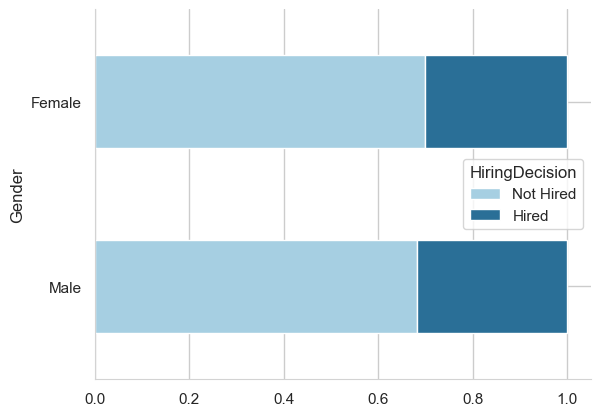

In [22]:
GHCounts = pd.crosstab(df['Gender'], df['HiringDecision'])
GH = GHCounts.div(GHCounts.sum(axis = 1), axis = 0)
GH.rename(index={
    '0': 'Male',
    '1': 'Female'
}, columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
GH.plot(kind = 'barh', stacked = True, color=custom_palette)
plt.xticks(rotation=0)
plt.savefig("Gender and HiringDecision")
plt.show()

In [186]:
# Gender Not Significant With HiringDecision (chisq wise)
chi2_contingency(GH)

Chi2ContingencyResult(statistic=0.3775628079296607, pvalue=0.5389104750337366, dof=1, expected_freq=array([[426.42, 191.58],
       [401.58, 180.42]]))

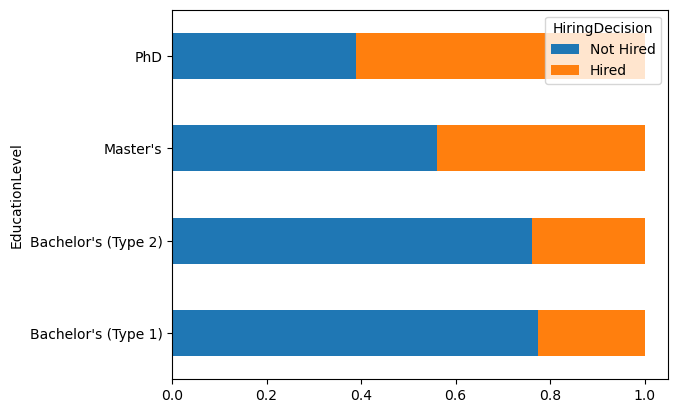

In [251]:
EHCounts = pd.crosstab(df['EducationLevel'], df['HiringDecision'])
EH = EHCounts.div(EHCounts.sum(axis = 1), axis = 0)

EH.rename(index={
    '1': "Bachelor's (Type 1)",
    '2': "Bachelor's (Type 2)",
    '3': "Master's",
    '4': "PhD"
}, columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
EH.plot(kind = 'barh', stacked = True)
plt.xticks(rotation=0)
plt.show()

In [255]:
chi2_contingency(EHCounts)

Chi2ContingencyResult(statistic=87.88536401947968, pvalue=6.2329539903693145e-19, dof=3, expected_freq=array([[171.12,  76.88],
       [414.69, 186.31],
       [167.67,  75.33],
       [ 74.52,  33.48]]))

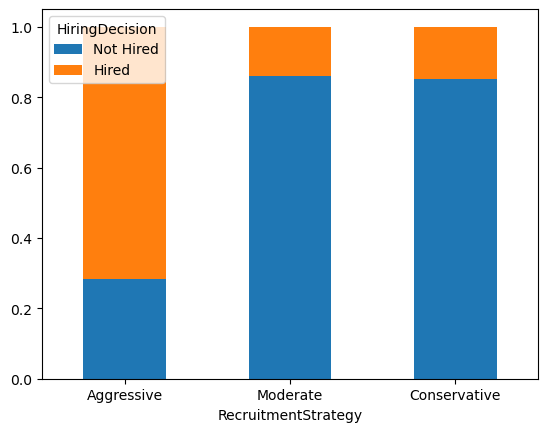

In [265]:
RHCounts = pd.crosstab(df['RecruitmentStrategy'], df['HiringDecision'])
RH = RHCounts.div(RHCounts.sum(axis = 1), axis = 0)
RH.rename(index={
    '1': 'Aggressive',
    '2': 'Moderate',
    '3': 'Conservative'
}, columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
RH.plot(kind = 'bar', stacked = True)
plt.xticks(rotation=0)
plt.show()

In [261]:
chi2_contingency(RHCounts)

Chi2ContingencyResult(statistic=386.06892994688747, pvalue=1.466212929373325e-84, dof=2, expected_freq=array([[242.19, 108.81],
       [427.8 , 192.2 ],
       [158.01,  70.99]]))

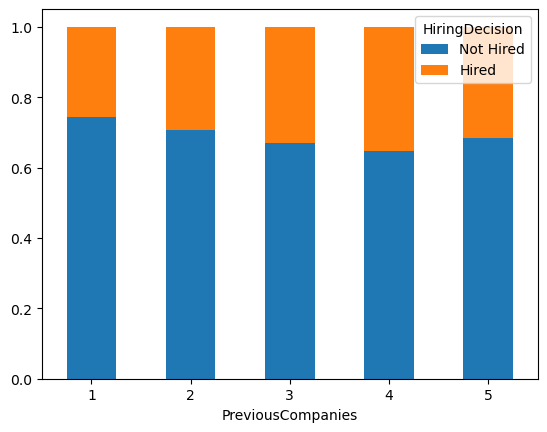

In [247]:
HPCounts = pd.crosstab(df['PreviousCompanies'], df['HiringDecision'])
HP = HPCounts.div(HPCounts.sum(axis = 1), axis = 0)

HP.rename(columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
HP.plot(kind = 'bar', stacked = True)
plt.xticks(rotation=0)
plt.show()

In [249]:
chi2_contingency(HPCounts)

Chi2ContingencyResult(statistic=6.081284832890612, pvalue=0.19315955473479884, dof=4, expected_freq=array([[159.39,  71.61],
       [169.05,  75.95],
       [166.98,  75.02],
       [166.29,  74.71],
       [166.29,  74.71]]))

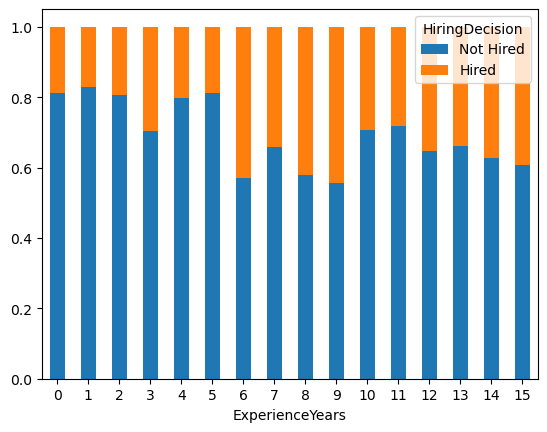

In [242]:
ExpHCounts = pd.crosstab(df['ExperienceYears'], df['HiringDecision'])
ExpH = ExpHCounts.div(ExpHCounts.sum(axis=1), axis=0)
ExpH.rename(columns = {'0' : 'Not Hired','1' : 'Hired'}, inplace=True)
ExpH.plot(kind = 'bar', stacked = True)
plt.xticks(rotation=0)
plt.show()

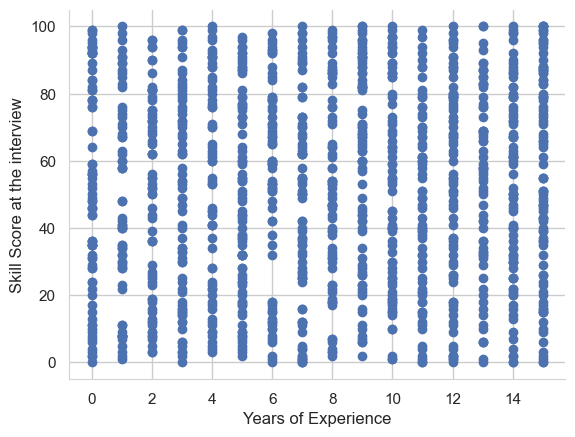

In [34]:
plt.scatter(x = 'ExperienceYears',y = 'SkillScore', data = df)
plt.xlabel("Years of Experience")
plt.ylabel("Skill Score at the interview")
plt.show()

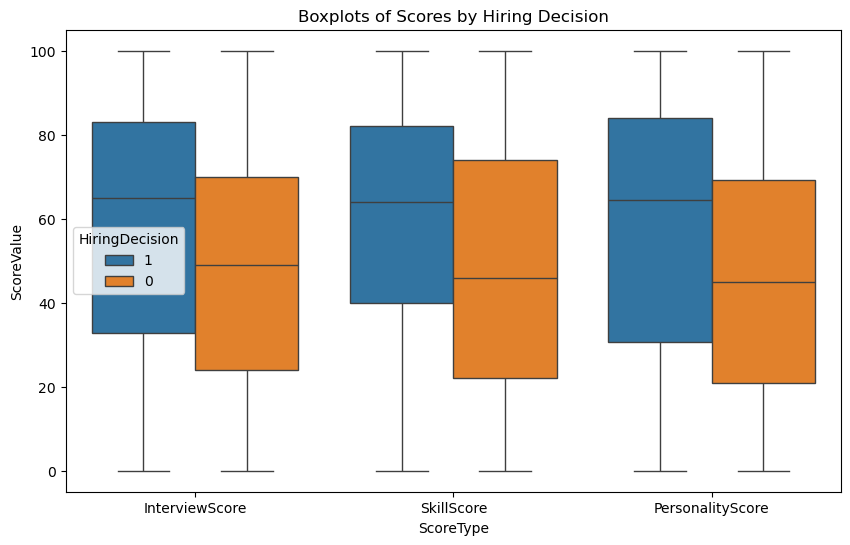

In [213]:
import seaborn as sns
df_melted = df.melt(id_vars='HiringDecision', value_vars=['InterviewScore', 'SkillScore', 'PersonalityScore'],
                    var_name='ScoreType', value_name='ScoreValue')

plt.figure(figsize=(10, 6))
sns.boxplot(x='ScoreType', y='ScoreValue', hue='HiringDecision', data=df_melted)
plt.title('Boxplots of Scores by Hiring Decision')
plt.show()


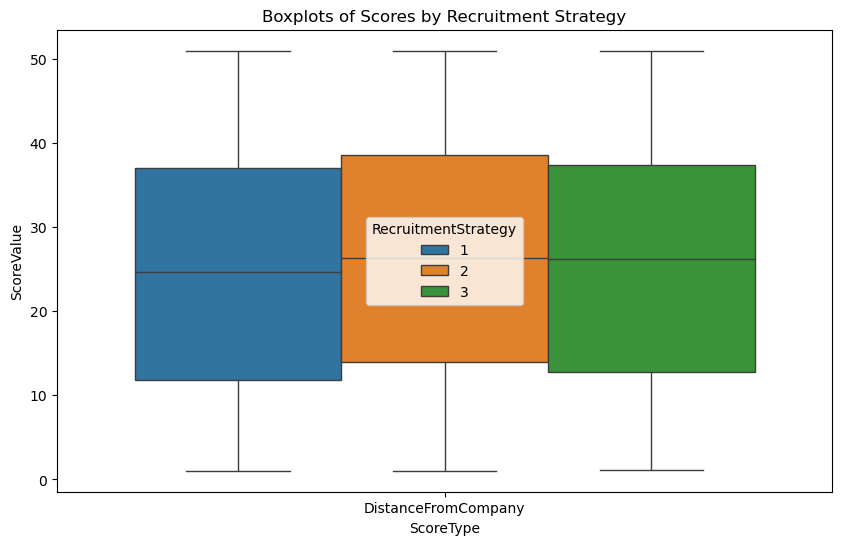

In [211]:
df_melted = df.melt(id_vars='RecruitmentStrategy', value_vars=['DistanceFromCompany'],
                    var_name='ScoreType', value_name='ScoreValue')

plt.figure(figsize=(10, 6))
sns.boxplot(x='ScoreType', y='ScoreValue', hue='RecruitmentStrategy', data=df_melted)
plt.title('Boxplots of Scores by Recruitment Strategy')
plt.show()

<Axes: ylabel='Density'>

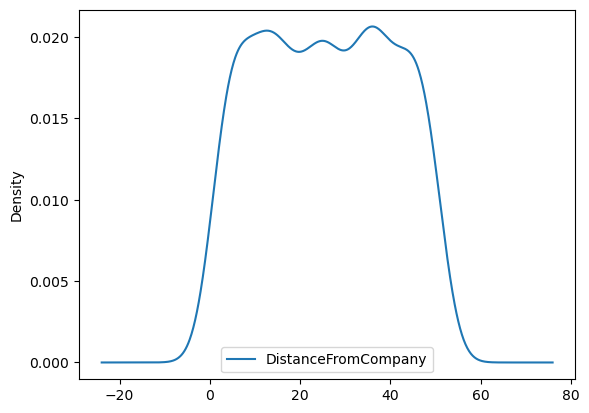

In [277]:
df.plot(y = 'DistanceFromCompany', kind = 'kde')